<a href="https://colab.research.google.com/github/abhisheknk07/AI-ML-Projects/blob/main/Electricity_Bill_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Based Electricity Consumption and Bill Forecasting System
**Name**-Abhishek Nayak

**Roll no**-A6/JY-11001

**Batch**-July 2026

##*Artificial Intelligence InternsElite*




Minor Project : 1
#                            Electricity Bill Forecaster









#1. Introduction

Electricity consumption changes over time and is influenced by household usage patterns and seasonal effects. Forecasting monthly electricity consumption can help users estimate future electricity costs and manage energy use. This project develops an Electricity Bill Forecaster using historical household electricity usage data and Multiple Linear Regression.

The UCI Individual Household Electric Power Consumption dataset is used as the historical source. The original data contains one-minute electrical measurements collected over about 47 months. The minute-level active power values are converted into daily energy consumption in kWh. Previous-day consumption, short-term rolling average, day of week, and month are then used as input features. A Multiple Linear Regression model is trained using a chronological train-test split so that future information is not used to predict the past.

The model predicts daily electricity consumption, which is then aggregated to obtain monthly consumption. An estimated monthly electricity cost is calculated using a clearly stated average tariff assumption. Model performance is evaluated using MAE, RMSE, and R². Graphs compare actual and predicted monthly electricity consumption and cost.


#2. Problem Statement
The main objective of this project is to develop an **Electricity Bill Forecaster** using historical household electricity consumption data and Multiple Linear Regression. The dataset contains 2,075,259 historical electricity measurements, which are processed to obtain daily electricity consumption.

The model uses previous electricity consumption and calendar-based features as The model uses previous electricity consumption, recent average consumption, day of the week, and month as input features to predict future electricity consumption. The predicted daily consumption is then combined to estimate the monthly electricity consumption and electricity cost.

Thus, the project aims to use historical electricity usage patterns to forecast future monthly consumption and estimate the corresponding electricity cost.
















#3. Results and Discussion

The historical household electricity dataset was processed to calculate daily electricity consumption and was then used to train a Multiple Linear Regression model. The model used previous electricity consumption, recent average consumption, day of the week, and month as input features.

The model performance was evaluated using three measures:

a. Mean Absolute Error (MAE)

b. Root Mean Squared Error (RMSE)

c. R-squared (R²)


• Monthly electricity consumption error

• Average monthly cost error

The project generates two graphs:

Figure 1: Actual vs Predicted Monthly Electricity Consumption

Figure 2: Actual vs Predicted Monthly Electricity Cost

The results demonstrate that the model can capture the overall monthly electricity consumption pattern and can be used to estimate monthly electricity cost from historical usage data.

For cost estimation, the project uses an assumed average tariff of ₹6.50 per kWh for demonstration. This is not claimed to be an official tariff for a specific electricity board. A real deployment should use the correct local tariff structure.



Dataset downloaded and extracted successfully.

Original dataset shape: (2075259, 9)

Daily consumption preview:
    DateOnly  Daily_Consumption_kWh
0 2006-12-16              20.152933
1 2006-12-17              56.507667
2 2006-12-18              36.730433
3 2006-12-19              27.769900
4 2006-12-20              37.095800
----------------------------------------------------------------------

Model Performance Metrics:
Mean Absolute Error (MAE): 4.6591 kWh
Root Mean Squared Error (RMSE): 6.4266 kWh
R-squared Score (R²): 0.3225
----------------------------------------------------------------------

Monthly Forecast Results:
  Month  Actual_Consumption_kWh  Predicted_Consumption_kWh  Actual_Cost_INR  Predicted_Cost_INR
2010-02                  666.06                     673.98          4329.39             4380.89
2010-03                  802.60                     777.80          5216.89             5055.68
2010-04                  739.64                     773.29          4807.63 

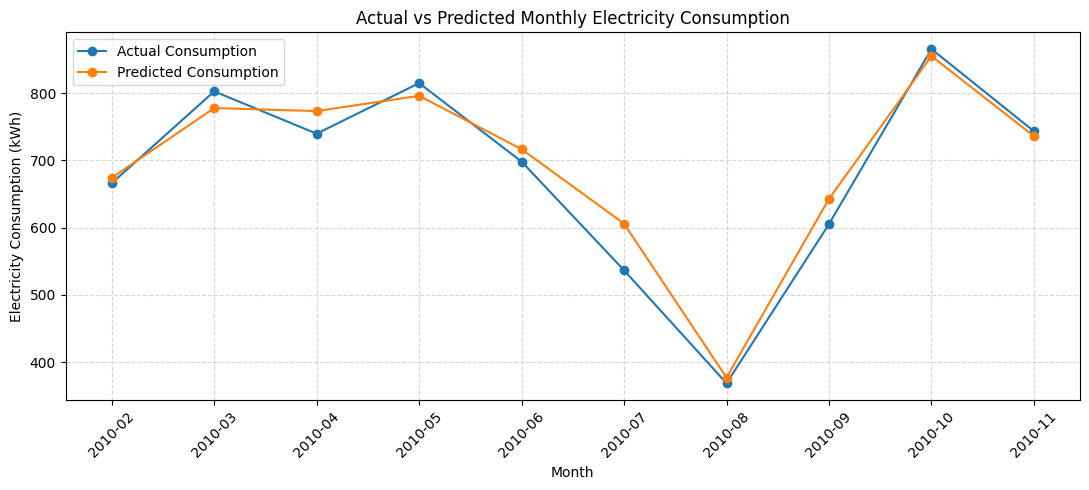

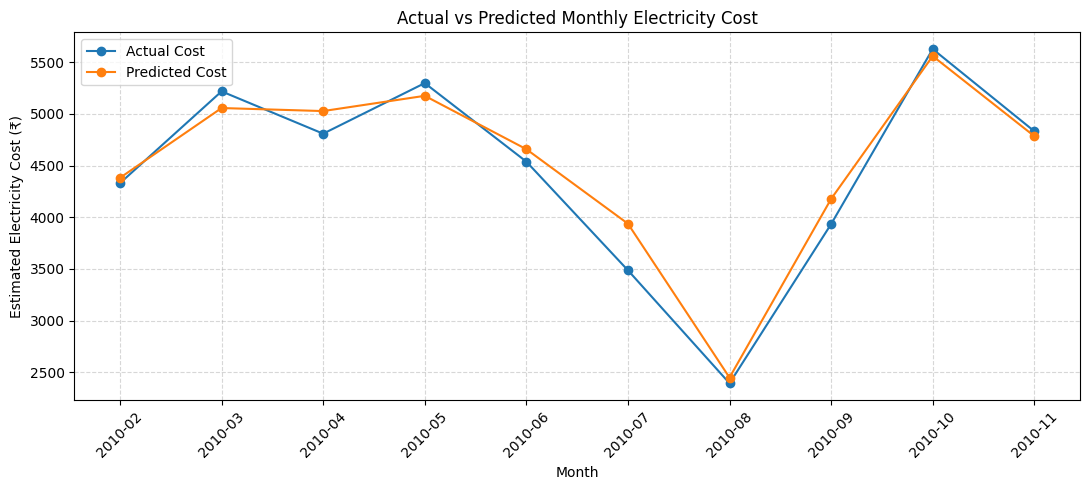

Project outputs saved in /content/electricity_project_outputs


In [2]:
# Import necessary libraries
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Download the historical household electricity dataset
url = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
zip_path = "/content/electricity_data.zip"
extract_dir = "/content/electricity_data"

if not os.path.exists(extract_dir):
    print("Downloading historical electricity dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    print("Dataset downloaded and extracted successfully.")
else:
    print("Dataset already available.")

file_path = os.path.join(extract_dir, "household_power_consumption.txt")

# 2. Load the historical usage data
df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("\nOriginal dataset shape:", df.shape)

# 3. Combine Date and Time
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

# Convert electricity fields to numeric
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 4. Remove rows with missing target values
df = df.dropna(subset=["Datetime", "Global_active_power"]).copy()

# Global active power is in kW. Sum minute readings over a day:
# kWh/day = sum(kW readings) / 60
df["DateOnly"] = df["Datetime"].dt.date

daily = (
    df.groupby("DateOnly")["Global_active_power"]
      .sum()
      .div(60)
      .reset_index(name="Daily_Consumption_kWh")
)

daily["DateOnly"] = pd.to_datetime(daily["DateOnly"])
daily = daily.sort_values("DateOnly").reset_index(drop=True)

print("\nDaily consumption preview:")
print(daily.head())
print("-" * 70)

# 5. Create historical lag features
# These use only information that would have been known before the target day.
daily["Lag_1_Day_kWh"] = daily["Daily_Consumption_kWh"].shift(1)
daily["Lag_2_Day_kWh"] = daily["Daily_Consumption_kWh"].shift(2)
daily["Lag_3_Day_kWh"] = daily["Daily_Consumption_kWh"].shift(3)
daily["Rolling_7_Day_Mean_kWh"] = (
    daily["Daily_Consumption_kWh"].shift(1).rolling(7).mean()
)

# Calendar features
daily["Day_of_Week"] = daily["DateOnly"].dt.dayofweek
daily["Month"] = daily["DateOnly"].dt.month

daily = daily.dropna().reset_index(drop=True)

# 6. Define features and target
features = [
    "Lag_1_Day_kWh",
    "Lag_2_Day_kWh",
    "Lag_3_Day_kWh",
    "Rolling_7_Day_Mean_kWh",
    "Day_of_Week",
    "Month"
]

X = daily[features]
y = daily["Daily_Consumption_kWh"]

# 7. Chronological train-test split
# First 80% = training history, last 20% = future/test period.
split_index = int(len(daily) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 8. Train Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 9. Predict daily electricity consumption
y_pred = model.predict(X_test)

# 10. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kWh")
print(f"R-squared Score (R²): {r2:.4f}")
print("-" * 70)

# 11. Create a daily results table
results = pd.DataFrame({
    "Date": daily.loc[X_test.index, "DateOnly"].values,
    "Actual_Daily_Consumption_kWh": y_test.values,
    "Predicted_Daily_Consumption_kWh": y_pred
})

# 12. Convert daily results into monthly actual vs predicted consumption
results["Month"] = results["Date"].dt.to_period("M")

monthly = (
    results.groupby("Month")
           .agg(
               Actual_Consumption_kWh=("Actual_Daily_Consumption_kWh", "sum"),
               Predicted_Consumption_kWh=("Predicted_Daily_Consumption_kWh", "sum")
           )
           .reset_index()
)

# 13. Estimate monthly electricity cost
# This is an assumed average tariff for project demonstration.
# Replace with your local tariff when you finalize your report/app.
TARIFF_PER_KWH = 6.50

monthly["Actual_Cost_INR"] = monthly["Actual_Consumption_kWh"] * TARIFF_PER_KWH
monthly["Predicted_Cost_INR"] = monthly["Predicted_Consumption_kWh"] * TARIFF_PER_KWH

print("\nMonthly Forecast Results:")
print(monthly.head(12).round(2).to_string(index=False))
print("-" * 70)

# 14. Monthly forecast error
monthly_mae_kwh = mean_absolute_error(
    monthly["Actual_Consumption_kWh"],
    monthly["Predicted_Consumption_kWh"]
)
monthly_rmse_kwh = np.sqrt(mean_squared_error(
    monthly["Actual_Consumption_kWh"],
    monthly["Predicted_Consumption_kWh"]
))
monthly_r2 = r2_score(
    monthly["Actual_Consumption_kWh"],
    monthly["Predicted_Consumption_kWh"]
)

monthly_mae_cost = mean_absolute_error(
    monthly["Actual_Cost_INR"],
    monthly["Predicted_Cost_INR"]
)

print("\nMonthly Model Performance:")
print(f"Monthly MAE: {monthly_mae_kwh:.2f} kWh")
print(f"Monthly RMSE: {monthly_rmse_kwh:.2f} kWh")
print(f"Monthly R²: {monthly_r2:.4f}")
print(f"Average Monthly Cost Error: ₹{monthly_mae_cost:.2f}")
print("-" * 70)

# 15. Graph: Actual vs Predicted Monthly Consumption
plt.figure(figsize=(11, 5))
plt.plot(
    monthly["Month"].astype(str),
    monthly["Actual_Consumption_kWh"],
    marker="o",
    label="Actual Consumption"
)
plt.plot(
    monthly["Month"].astype(str),
    monthly["Predicted_Consumption_kWh"],
    marker="o",
    label="Predicted Consumption"
)
plt.title("Actual vs Predicted Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Electricity Consumption (kWh)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 16. Optional graph: Actual vs Predicted Monthly Cost
plt.figure(figsize=(11, 5))
plt.plot(
    monthly["Month"].astype(str),
    monthly["Actual_Cost_INR"],
    marker="o",
    label="Actual Cost"
)
plt.plot(
    monthly["Month"].astype(str),
    monthly["Predicted_Cost_INR"],
    marker="o",
    label="Predicted Cost"
)
plt.title("Actual vs Predicted Monthly Electricity Cost")
plt.xlabel("Month")
plt.ylabel("Estimated Electricity Cost (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 17. Save useful outputs
os.makedirs("/content/electricity_project_outputs", exist_ok=True)

monthly.to_csv(
    "/content/electricity_project_outputs/monthly_forecast_results.csv",
    index=False
)

pd.DataFrame({
    "Metric": [
        "Daily MAE (kWh)",
        "Daily RMSE (kWh)",
        "Daily R²",
        "Monthly MAE (kWh)",
        "Monthly RMSE (kWh)",
        "Monthly R²",
        "Average Monthly Cost Error (INR)"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        monthly_mae_kwh,
        monthly_rmse_kwh,
        monthly_r2,
        monthly_mae_cost
    ]
}).to_csv(
    "/content/electricity_project_outputs/model_metrics.csv",
    index=False
)

print("Project outputs saved in /content/electricity_project_outputs")


#4. Conclusion

This project demonstrates how Multiple Linear Regression can be applied to historical household electricity usage for forecasting. Minute-level electricity measurements are converted into daily consumption, historical lag features are created, and a chronological train-test split is used to predict future usage. The predicted daily values are aggregated to produce monthly electricity consumption and an estimated monthly cost.

The project provides a simple foundation for electricity forecasting and can be improved in the future using weather data, appliance-level information, tariff slabs, seasonal features, and advanced forecasting models such as Random Forest, XGBoost, or time-series deep learning methods.



















#5. REFERENCE
Hebrail, G. & Berard, A. (2006). Individual Household Electric Power Consumption [Dataset]. UCI Machine Learning Repository.